# 1. Introduction

### Task A:
Cluster the data using the five features — distance, fare, tip, rate code, and pickup zone — while testing multiple distance metrics and evaluating the clustering performance.
### Task B:
Use the Random Forest supervised learning model (with the same hyperparameters from the previous assignment) to predict the payment_type label.
### Task C:
Map the clusters from Task A to payment_type and compare the results of unsupervised clustering with the supervised learning model.

# 2. Load & EDA

In [51]:
import pandas as pd
df = pd.read_csv('../data/raw/yellow_tripdata_2025-09.csv')
df.head()

/var/folders/cy/h4rtzttd0b95fwnjhlv7y8lw0000gn/T/ipykernel_3845/2009240588.py:2: DtypeWarning: Columns (3,5,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/yellow_tripdata_2025-09.csv')


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2025-09-11 12:26:19.000000,2025-09-11 12:56:08.000000,1,2.67,1,N,142,140,1,25.4,0.0,0.5,6.03,0.0,1.0,36.18,2.5,0.0,0.75
1,2,2025-09-11 12:09:54.000000,2025-09-11 12:48:25.000000,2,1.27,1,N,186,163,1,30.3,0.0,0.5,5.26,0.0,1.0,40.31,2.5,0.0,0.75
2,1,2025-09-11 12:51:50.000000,2025-09-11 14:17:45.000000,1,26.20,99,N,86,26,1,72.5,0.0,0.5,0.00,0.0,0.0,73.00,0.0,0.0,0.00
3,1,2025-09-11 12:27:37.000000,2025-09-11 12:31:27.000000,1,0.40,1,N,141,140,1,5.1,2.5,0.5,2.00,0.0,1.0,11.10,2.5,0.0,0.00
4,1,2025-09-11 12:36:09.000000,2025-09-11 12:51:53.000000,2,1.10,1,N,140,237,1,13.5,2.5,0.5,1.75,0.0,1.0,19.25,2.5,0.0,0.00


In [52]:
cols = ['trip_distance', 'fare_amount', 'tip_amount', 'RatecodeID', 'PULocationID', 'payment_type']
df = df[cols]
df.head()

,trip_distance,fare_amount,tip_amount,RatecodeID,PULocationID,payment_type
0,2.67,25.4,6.03,1,142,1
1,1.27,30.3,5.26,1,186,1
2,26.20,72.5,0.00,99,86,1
3,0.40,5.1,2.00,1,141,1
4,1.10,13.5,1.75,1,140,1


In [53]:
df.isna().sum()

trip_distance    0
fare_amount      0
tip_amount       0
RatecodeID       0
PULocationID     0
payment_type     0
dtype: int64

In [54]:
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]
df = df[(df['tip_amount'] > 0) & (df['tip_amount'] <= df['fare_amount'])]
df = df[df['RatecodeID'].isin([1,2,3,4,5,6])]
df = df[(df['PULocationID'] >= 1) & (df['PULocationID'] <= 265)]
df.head()

,trip_distance,fare_amount,tip_amount,RatecodeID,PULocationID,payment_type
0,2.67,25.4,6.03,1,142,1
1,1.27,30.3,5.26,1,186,1
3,0.40,5.1,2.00,1,141,1
4,1.10,13.5,1.75,1,140,1
5,16.62,69.5,7.00,1,132,1


In [55]:
df.describe()

,trip_distance,fare_amount,tip_amount,PULocationID,payment_type
count,2.433037e+06,2.433037e+06,2.433037e+06,2.433037e+06,2.433037e+06
mean,3.325177e+00,1.997289e+01,4.761155e+00,1.670856e+02,1.000092e+00
std,4.381060e+00,1.811089e+01,4.028706e+00,6.284412e+01,1.591142e-02
min,1.000000e-02,3.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00
25%,1.040000e+00,9.300000e+00,2.500000e+00,1.320000e+02,1.000000e+00
50%,1.720000e+00,1.420000e+01,3.570000e+00,1.620000e+02,1.000000e+00
75%,3.200000e+00,2.190000e+01,5.250000e+00,2.340000e+02,1.000000e+00
max,9.380000e+01,4.650000e+02,2.650000e+02,2.650000e+02,4.000000e+00


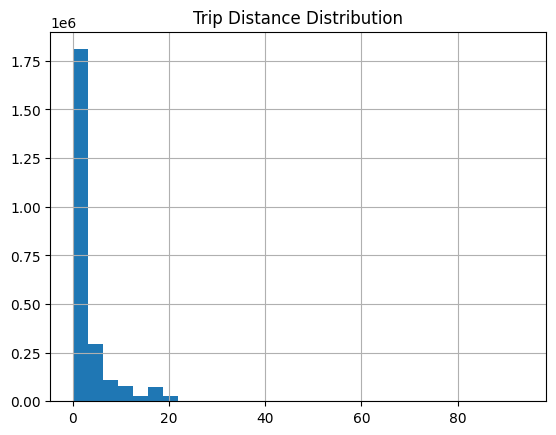

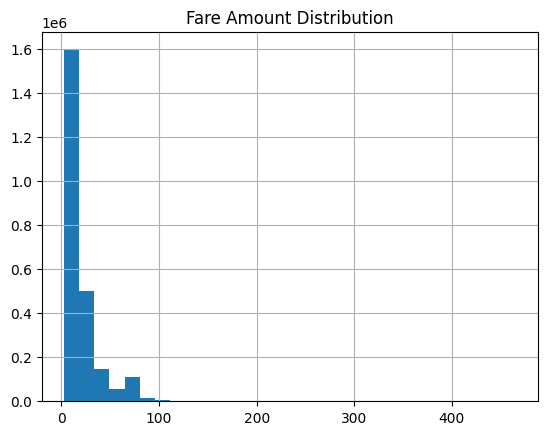

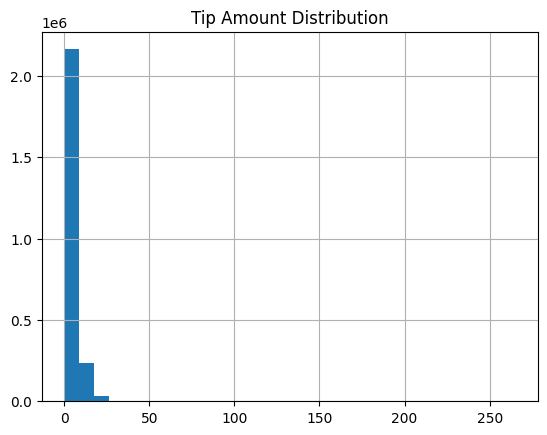

In [56]:
import matplotlib.pyplot as plt

df['trip_distance'].hist(bins = 30)
plt.title("Trip Distance Distribution")
plt.show()

df['fare_amount'].hist(bins = 30)
plt.title("Fare Amount Distribution")
plt.show()

df['tip_amount'].hist(bins = 30)
plt.title("Tip Amount Distribution")
plt.show()


In [57]:
print(df['RatecodeID'].value_counts())
print(df['PULocationID'].value_counts().head())


RatecodeID
1    2311995
2      86066
5      20414
3       8018
4       6544
Name: count, dtype: int64
PULocationID
237    139807
236    118539
132    116817
161    116234
186     95901
Name: count, dtype: int64


- Check basic data quality before clustering  
- No missing values  
- Remove outliers in 5 features  
- Statistical summary → continuous variables = right-skewed distribution  

# 3. Feature engineering

In [58]:
df = df.reset_index(drop = True)
df.head()

,trip_distance,fare_amount,tip_amount,RatecodeID,PULocationID,payment_type
0,2.67,25.4,6.03,1,142,1
1,1.27,30.3,5.26,1,186,1
2,0.40,5.1,2.00,1,141,1
3,1.10,13.5,1.75,1,140,1
4,16.62,69.5,7.00,1,132,1


In [59]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ['trip_distance', 'fare_amount', 'tip_amount']

scaler = StandardScaler()

scaled_cont = scaler.fit_transform(df[continuous_cols])

df_scaled_cont = pd.DataFrame(
    scaled_cont,
    columns = [col + "_scaled" for col in continuous_cols]
)

df = pd.concat([df, df_scaled_cont], axis=1)
df_scaled_cont.head()


,trip_distance_scaled,fare_amount_scaled,tip_amount_scaled
0,-0.149548,0.299660,0.314951
1,-0.469105,0.570216,0.123823
2,-0.667687,-0.821213,-0.685370
3,-0.507908,-0.357403,-0.747425
4,3.034614,2.734660,0.555723


In [60]:
print(df_scaled_cont.mean())
print(df_scaled_cont.std())


trip_distance_scaled   -6.445328e-17
fare_amount_scaled     -4.079656e-16
tip_amount_scaled       2.459271e-16
dtype: float64
trip_distance_scaled    1.0
fare_amount_scaled      1.0
tip_amount_scaled       1.0
dtype: float64


In [61]:
def frequency_encode(col):
    freq = df[col].value_counts() / len(df)
    return df[col].map(freq)

df['RatecodeID_FE'] = frequency_encode('RatecodeID')
df['PULocationID_FE'] = frequency_encode('PULocationID')

df[['RatecodeID', 'RatecodeID_FE', 'PULocationID', 'PULocationID_FE']].head()


,RatecodeID,RatecodeID_FE,PULocationID,PULocationID_FE
0,1,0.950251,142,0.031046
1,1,0.950251,186,0.039416
2,1,0.950251,141,0.023559
3,1,0.950251,140,0.019814
4,1,0.950251,132,0.048013


In [62]:
clust = pd.concat([
    df_scaled_cont,
    df[['RatecodeID_FE', 'PULocationID_FE']]
], axis = 1)

clust.head()


,trip_distance_scaled,fare_amount_scaled,tip_amount_scaled,RatecodeID_FE,PULocationID_FE
0,-0.149548,0.299660,0.314951,0.950251,0.031046
1,-0.469105,0.570216,0.123823,0.950251,0.039416
2,-0.667687,-0.821213,-0.685370,0.950251,0.023559
3,-0.507908,-0.357403,-0.747425,0.950251,0.019814
4,3.034614,2.734660,0.555723,0.950251,0.048013


- Transform variables for distance-based clustering  
- reset_index() after outlier removal  
- Continuous: trip_distance, fare_amount, tip_amount → StandardScaler (mean 0, std 1)  
- Categorical: RatecodeID, PULocationID → Frequency Encoding

# 4. Task A

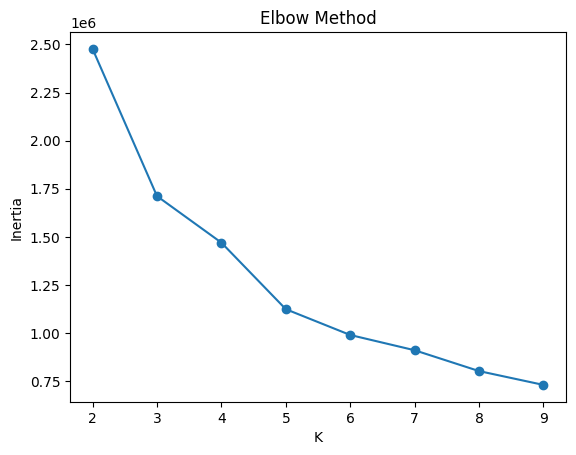

k = 2: inertia = 2476996.37084873
k = 3: inertia = 1711701.8016331317
k = 4: inertia = 1469598.6708480201
k = 5: inertia = 1123721.8402606267
k = 6: inertia = 989587.2270862429
k = 7: inertia = 910230.0303753212
k = 8: inertia = 801926.8060010676
k = 9: inertia = 729975.475519968


In [63]:
from sklearn.cluster import KMeans

inertias = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 'auto')
    km.fit(clust)
    inertias.append(km.inertia_)

plt.plot(K, inertias, marker = 'o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

for k, inertia in zip(K, inertias):
    print(f"k = {k}: inertia = {inertia}")


In [64]:
best_k = 5
km = KMeans(n_clusters = best_k, random_state = 42, n_init = 'auto')
km_labels = km.fit_predict(clust)

df['km_cluster'] = km_labels
km_summary = df.groupby('km_cluster')[['trip_distance','fare_amount','tip_amount']].mean()
km_summary


,trip_distance,fare_amount,tip_amount
km_cluster,,,
0,3.423835,22.933732,5.438609
1,17.646174,73.027154,15.474612
2,9.088191,45.906643,10.698057
3,30.760755,170.338233,34.122866
4,1.310362,10.815372,2.798725


- 4 cluster → “short/cheap trips”  
- 0 cluster → “medium trips”  
- 2 cluster → “mid-long trips”  
- 1 cluster → “long expensive trips”  
- 3 cluster → “extremely long premium trips”  

In [65]:
from sklearn_extra.cluster import KMedoids

sample = clust.sample(n = 20000, random_state = 42)

kmed = KMedoids(n_clusters = best_k, metric = 'manhattan', random_state = 42)
kmed_labels = kmed.fit_predict(sample)

df['kmed_cluster'] = -1

df.loc[sample.index, 'kmed_cluster'] = kmed_labels
kmed_summary = df[df['kmed_cluster'] != -1].groupby('kmed_cluster')[['trip_distance','fare_amount','tip_amount']].mean()
kmed_summary


,trip_distance,fare_amount,tip_amount
kmed_cluster,,,
0,1.655966,13.272721,3.812747
1,9.051551,43.805056,10.073703
2,1.025976,8.940629,2.159837
3,3.525023,23.321990,5.323842
4,17.435206,76.154381,15.820658


Reason why use sample KMedoids = O(n²) so full dataset 2.4M is impossible  
- -1 cluster is not sample it's baseline  
- 0,2 cluster → “short/cheap trips”  
- 1 cluster → “mid-long trips”  
- 3 cluster → “medium trips”  
- 4 cluster → “long expensive trips”  

In [66]:
comparison = pd.concat([
    km_summary.assign(model="KMeans-Euclidean"),
    kmed_summary.assign(model="KMedoids-Manhattan")
])
comparison


,trip_distance,fare_amount,tip_amount,model
0,3.423835,22.933732,5.438609,KMeans-Euclidean
1,17.646174,73.027154,15.474612,KMeans-Euclidean
2,9.088191,45.906643,10.698057,KMeans-Euclidean
3,30.760755,170.338233,34.122866,KMeans-Euclidean
4,1.310362,10.815372,2.798725,KMeans-Euclidean
0,1.655966,13.272721,3.812747,KMedoids-Manhattan
1,9.051551,43.805056,10.073703,KMedoids-Manhattan
2,1.025976,8.940629,2.159837,KMedoids-Manhattan
3,3.525023,23.321990,5.323842,KMedoids-Manhattan
4,17.435206,76.154381,15.820658,KMedoids-Manhattan


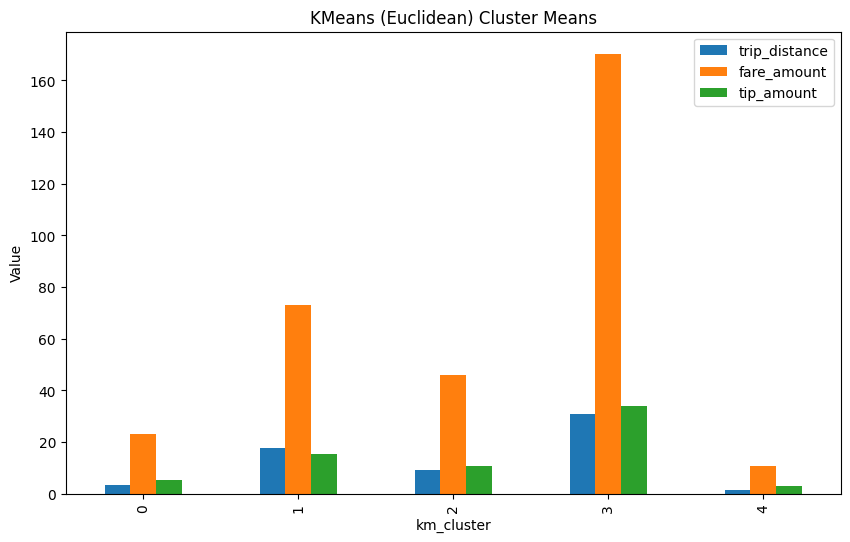

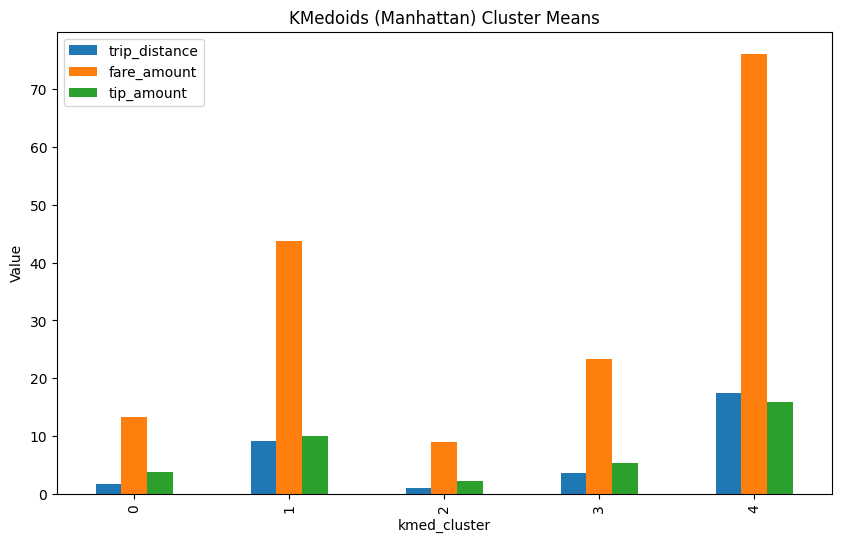

In [67]:
km_summary.plot(kind='bar', figsize=(10,6))
plt.title("KMeans (Euclidean) Cluster Means")
plt.ylabel("Value")
plt.show()

kmed_summary.plot(kind='bar', figsize=(10,6))
plt.title("KMedoids (Manhattan) Cluster Means")
plt.ylabel("Value")
plt.show()


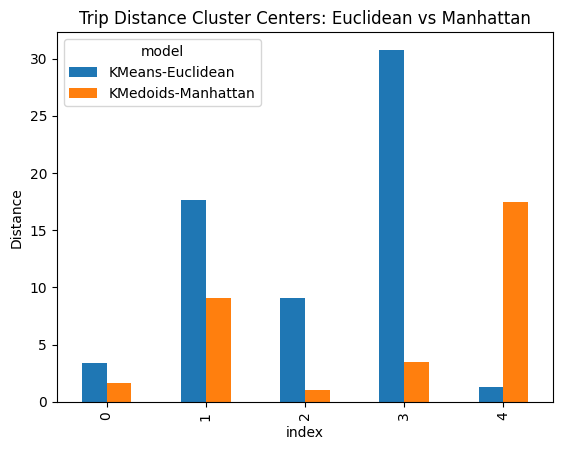

In [68]:
comparison.reset_index().pivot(index='index', columns='model', values='trip_distance').plot(kind='bar')
plt.title("Trip Distance Cluster Centers: Euclidean vs Manhattan")
plt.ylabel("Distance")
plt.show()


In [69]:
from sklearn.metrics import pairwise_distances

cont = clust[['trip_distance_scaled','fare_amount_scaled','tip_amount_scaled']].sample(5000)

dist_eu = pairwise_distances(cont, metric='euclidean')
dist_ma = pairwise_distances(cont, metric='manhattan')

print("Euclidean mean distance:", dist_eu.mean())
print("Manhattan mean distance:", dist_ma.mean())
print("Euclidean std:", dist_eu.std())
print("Manhattan std:", dist_ma.std())


Euclidean mean distance: 1.5665479323650742
Manhattan mean distance: 2.572145306767379
Euclidean std: 1.7699163510289253
Manhattan std: 3.0127020404157014


In [70]:
from sklearn.metrics import pairwise_distances

cat = clust[['RatecodeID_FE','PULocationID_FE']].sample(20000)

dist_eu_cat = pairwise_distances(cat, metric='euclidean')
dist_ma_cat = pairwise_distances(cat, metric='manhattan')

print("Euclidean categorical mean distance:", dist_eu_cat.mean())
print("Manhattan categorical mean distance:", dist_ma_cat.mean())
print("Euclidean categorical std:", dist_eu_cat.std())
print("Manhattan categorical std:", dist_ma_cat.std())


Euclidean categorical mean distance: 0.10770502511769896
Manhattan categorical mean distance: 0.10971453526535742
Euclidean categorical std: 0.27307511581740995
Manhattan categorical std: 0.2790639644163968


- Compared two clustering methods: KMeans (Euclidean) and KMedoids (Manhattan)  
- KMeans used the full dataset; KMedoids used a 20,000-row sample due to its O(n²) computational cost  
- Both methods identified similar trip patterns: short, medium, long, and very long trips  
- Continuous features:  
Euclidean produced more stable distances (lower mean and variance)  
Manhattan showed larger variance and longer tails  
→ Euclidean works better for continuous variables  
- Categorical features (frequency-encoded):  
Euclidean and Manhattan distances were almost identical  
→ Metric choice has little effect for categorical variables  
- Conclusion:  
Euclidean (KMeans) gives clearer and more consistent clusters  
Manhattan (KMedoids) is more robust to outliers but computationally expensive.

# 5. Task B

In [73]:
print(df.columns.tolist())


['trip_distance', 'fare_amount', 'tip_amount', 'RatecodeID', 'PULocationID', 'payment_type', 'trip_distance_scaled', 'fare_amount_scaled', 'tip_amount_scaled', 'RatecodeID_FE', 'PULocationID_FE', 'km_cluster', 'kmed_cluster']


In [76]:
df['payment_type'].value_counts()

payment_type
1    2432946
4         63
2         21
3          7
Name: count, dtype: int64

In [74]:
from sklearn.model_selection import train_test_split

X = df[['trip_distance_scaled','fare_amount_scaled','tip_amount_scaled',
        'RatecodeID_FE','PULocationID_FE']]
y = df['payment_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

# best RF 모델 정의 (이전 과제에서 선택)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# 학습
rf.fit(X_train, y_train)

# 예측
y_pred = rf.predict(X_test)

# 평가
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print(classification_report(y_test, y_pred))


Macro F1: 0.2499951191793645


/Users/gwonnahyeong/miniforge3/envs/taxi/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/gwonnahyeong/miniforge3/envs/taxi/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00    486590
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        13

    accuracy                           1.00    486608
   macro avg       0.25      0.25      0.25    486608
weighted avg       1.00      1.00      1.00    486608



/Users/gwonnahyeong/miniforge3/envs/taxi/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
- Used best supervised model from previous assignment: RandomForest  
- Applied same hyperparameters: n_estimators=200, max_depth=None, min_samples_leaf=1  
- Features: scaled continuous variables + frequency-encoded categorical variables  
- Target: payment_type (highly imbalanced)  
- Model prediction behavior: predicts only class 1 (majority)  
- Performance:  
Accuracy = high (misleading)  
Macro-F1 = low (≈0.25)  
Minority classes (2,3,4) → F1 = 0  
- Reason:  
Extreme class imbalance  
Features have weak signal for payment_type separation  
RF cannot learn boundaries for rare classes  
- Conclusion:  
Supervised baseline is weak for minority classes  
Useful as comparison point for Task C (clustering vs supervised)

# 6. Task C

# 7. Conclusion